**1. Import Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

**2. Load Dataset**

In [3]:
# Load dataset from local file
df = pd.read_csv("spam.csv", encoding="latin-1")

# Select only relevant columns
df = df[['v1','v2']]

# Rename columns
df.columns = ['label','message']

# Display first rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**3. Data Exploration**

In [4]:
# Dataset information
df.info()

# Count spam and ham messages
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,count
label,
ham,4825
spam,747


**4. Data Visualization**

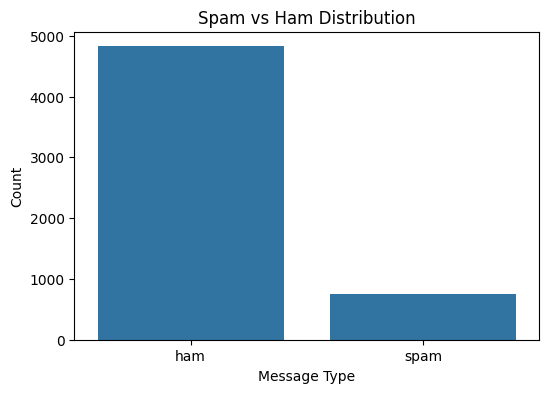

In [5]:
# Spam vs Ham distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

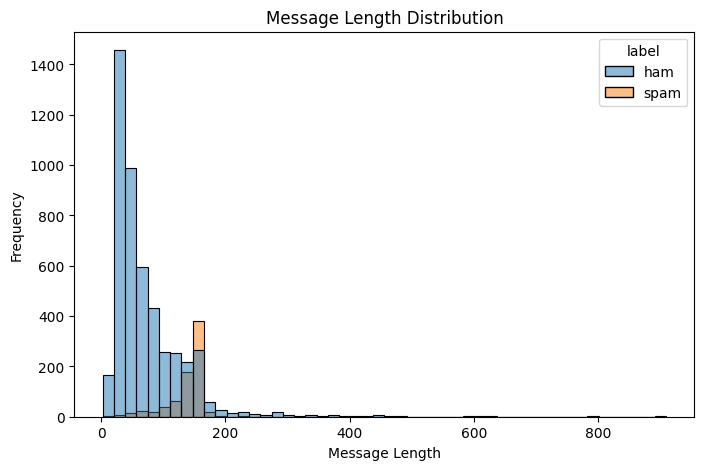

In [6]:
# Message length visualization
df['length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(data=df, x='length', hue='label', bins=50)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

**5. Data Prepocessing**

In [7]:
# Convert labels to numeric values
df['label'] = df['label'].map({'ham':0,'spam':1})

# Convert text into bag-of-words representation
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['message']).toarray()
y = df['label']

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**6. Naive Bayes Implementation**

In [8]:
# Calculate prior probabilities
num_spam = np.sum(y_train == 1)
num_ham = np.sum(y_train == 0)

total_messages = len(y_train)

P_spam = num_spam / total_messages
P_ham = num_ham / total_messages


# Separate spam and ham data
X_train_spam = X_train[y_train == 1]
X_train_ham = X_train[y_train == 0]


# Word counts
spam_word_count = np.sum(X_train_spam, axis=0)
ham_word_count = np.sum(X_train_ham, axis=0)

total_spam_words = np.sum(spam_word_count)
total_ham_words = np.sum(ham_word_count)

vocab_size = X_train.shape[1]


# Laplace smoothing
P_word_given_spam = (spam_word_count + 1) / (total_spam_words + vocab_size)
P_word_given_ham = (ham_word_count + 1) / (total_ham_words + vocab_size)

**7. Prediction & Evaluation**

In [9]:
def predict(message_vector):

    spam_score = np.log(P_spam)
    ham_score = np.log(P_ham)

    for i in range(len(message_vector)):
        if message_vector[i] > 0:
            spam_score += message_vector[i] * np.log(P_word_given_spam[i])
            ham_score += message_vector[i] * np.log(P_word_given_ham[i])

    if spam_score > ham_score:
        return 1
    else:
        return 0


# Predict test data
predictions = []

for message in X_test:
    predictions.append(predict(message))


# Evaluation
TP = TN = FP = FN = 0

for i in range(len(y_test)):

    actual = y_test.iloc[i]
    predicted = predictions[i]

    if actual == 1 and predicted == 1:
        TP += 1
    elif actual == 0 and predicted == 0:
        TN += 1
    elif actual == 0 and predicted == 1:
        FP += 1
    else:
        FN += 1


accuracy = (TP + TN) / len(y_test)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("Accuracy:", accuracy * 100, "%")
print("Precision:", precision * 100, "%")
print("Recall:", recall * 100, "%")

Accuracy: 97.847533632287 %
Precision: 91.44736842105263 %
Recall: 92.66666666666666 %


**8. Confusion Matrix Visualization**

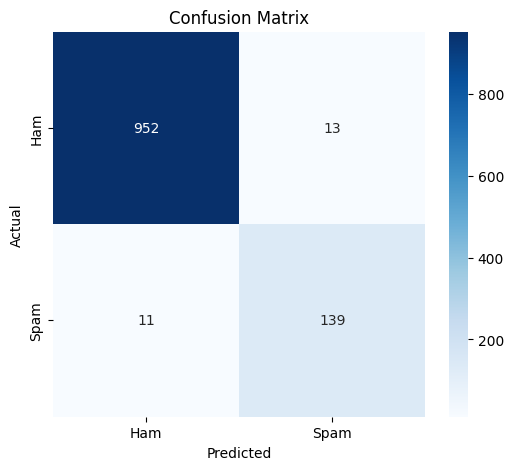

In [10]:
conf_matrix = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(6,5))

sns.heatmap(conf_matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Ham","Spam"],
            yticklabels=["Ham","Spam"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()